# Hyperparameter Experiments

E6 studies optimization hyperparameters for ImageNet-pretrained ResNet-50 with full fine-tuning.

The primary variables are learning rate and weight decay.

```mermaid
flowchart LR
    A["Fixed Full Fine-Tuning"] --> B["Learning Rate Sweep"]
    B --> C["Select Learning Rate"]
    C --> D["Weight Decay Sweep"]
    D --> E["Select Final Configuration"]
    E --> F["Official Test"]
```


## Experimental Design

Architecture, dataset split, input resolution, augmentation, and fine-tuning depth are fixed.

Learning rate is explored first:

$$
\eta\in\{3\times10^{-4},\;10^{-3},\;3\times10^{-3}\}
$$

The best learning rate is then fixed while weight decay is explored:

$$
\lambda\in\{10^{-5},\;10^{-4},\;10^{-3}\}
$$

The official test set is not used during hyperparameter selection.


In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.datasets import OxfordIIITPet
from torchvision.models import ResNet50_Weights, resnet50

SEED = 42
DATA_ROOT = Path("../data/raw")
IMAGE_SIZE = 224
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
BATCH_SIZE = 16
NUM_WORKERS = 2
PIN_MEMORY = torch.cuda.is_available()
NUM_EPOCHS = 30
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Seed:", SEED)
print("Device:", device)


Seed: 42
Device: cuda


## Dataset Setup

In [2]:
dataset_trainval = OxfordIIITPet(
    root=DATA_ROOT,
    split="trainval",
    target_types="category",
    download=False,
)

dataset_test = OxfordIIITPet(
    root=DATA_ROOT,
    split="test",
    target_types="category",
    download=False,
)

indices = np.arange(len(dataset_trainval))
labels = np.array(dataset_trainval._labels)

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.2,
    random_state=SEED,
    stratify=labels,
)

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class OxfordPetSubset(Dataset):
    def __init__(self, base_dataset, indices, transform=None):
        self.base_dataset = base_dataset
        self.indices = np.asarray(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, index):
        image, label = self.base_dataset[self.indices[index]]
        if self.transform is not None:
            image = self.transform(image)
        return image, label

val_dataset = OxfordPetSubset(dataset_trainval, val_indices, eval_transform)
test_dataset = OxfordPetSubset(dataset_test, np.arange(len(dataset_test)), eval_transform)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print("Train samples:", len(train_indices))
print("Validation samples:", len(val_indices))
print("Test samples:", len(test_dataset))


Train samples: 2944
Validation samples: 736
Test samples: 3669


In [3]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


## Model and Training Functions

In [4]:
def build_model():
    model = resnet50(weights=ResNet50_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, 37)
    for parameter in model.parameters():
        parameter.requires_grad = True
    return model.to(device)

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            logits = model(images)
            loss = criterion(logits, labels)
            running_loss += loss.item() * images.size(0)
            correct += (logits.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total


In [5]:
criterion = nn.CrossEntropyLoss()
checkpoint_dir = Path("../experiments/checkpoints")
checkpoint_dir.mkdir(parents=True, exist_ok=True)
results_dir = Path("../experiments/results")
results_dir.mkdir(parents=True, exist_ok=True)


## Learning Rate Sweep

Weight decay remains fixed at $10^{-4}$.

Each candidate starts from fresh ImageNet-pretrained weights so that configurations are independent.


In [6]:
learning_rates = [3e-4, 1e-3, 3e-3]
lr_results = []
lr_histories = {}

for lr in learning_rates:
    print(f"\n=== Learning Rate: {lr:.1e} ===")

    model = build_model()
    train_loader = DataLoader(
        OxfordPetSubset(dataset_trainval, train_indices, train_transform),
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )

    optimizer = AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=WEIGHT_DECAY,
    )
    scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

    history = {"train_loss": [], "train_accuracy": [], "val_loss": [], "val_accuracy": [], "learning_rate": []}
    best_val_accuracy = 0.0
    best_epoch = 0
    checkpoint_path = checkpoint_dir / f"e6_lr_{lr:.0e}.pt"

    for epoch in range(NUM_EPOCHS):
        train_loss, train_accuracy = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_accuracy = evaluate(model, val_loader, criterion, device)
        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)
        history["learning_rate"].append(current_lr)

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_epoch = epoch + 1
            torch.save({
                "experiment": "E6",
                "stage": "learning_rate",
                "learning_rate": lr,
                "weight_decay": WEIGHT_DECAY,
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_accuracy": val_accuracy,
            }, checkpoint_path)

        scheduler.step()

        print(
            f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.2%} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.2%} | "
            f"LR: {current_lr:.2e}"
        )

    lr_histories[lr] = history
    lr_results.append({
        "learning_rate": lr,
        "weight_decay": WEIGHT_DECAY,
        "best_epoch": best_epoch,
        "best_val_accuracy": best_val_accuracy,
        "checkpoint": str(checkpoint_path),
    })

lr_results = pd.DataFrame(lr_results)
lr_results



=== Learning Rate: 3.0e-04 ===
Epoch [01/30] | Train Loss: 1.7243 | Train Acc: 52.85% | Val Loss: 0.7386 | Val Acc: 78.80% | LR: 3.00e-04
Epoch [02/30] | Train Loss: 1.0022 | Train Acc: 71.30% | Val Loss: 0.4813 | Val Acc: 86.68% | LR: 2.99e-04
Epoch [03/30] | Train Loss: 0.8485 | Train Acc: 74.90% | Val Loss: 0.3523 | Val Acc: 89.40% | LR: 2.97e-04
Epoch [04/30] | Train Loss: 0.7726 | Train Acc: 77.04% | Val Loss: 0.4391 | Val Acc: 86.82% | LR: 2.93e-04
Epoch [05/30] | Train Loss: 0.7109 | Train Acc: 79.28% | Val Loss: 0.4617 | Val Acc: 86.55% | LR: 2.87e-04
Epoch [06/30] | Train Loss: 0.6015 | Train Acc: 82.13% | Val Loss: 0.2799 | Val Acc: 91.71% | LR: 2.80e-04
Epoch [07/30] | Train Loss: 0.5726 | Train Acc: 82.88% | Val Loss: 0.3041 | Val Acc: 90.62% | LR: 2.71e-04
Epoch [08/30] | Train Loss: 0.5103 | Train Acc: 84.61% | Val Loss: 0.3494 | Val Acc: 89.54% | LR: 2.61e-04
Epoch [09/30] | Train Loss: 0.5141 | Train Acc: 84.75% | Val Loss: 0.2989 | Val Acc: 90.35% | LR: 2.50e-04
Epoch

,learning_rate,weight_decay,best_epoch,best_val_accuracy,checkpoint
0,0.0003,0.0001,27,0.930707,../experiments/checkpoints/e6_lr_3e-04.pt
1,0.0010,0.0001,30,0.906250,../experiments/checkpoints/e6_lr_1e-03.pt
2,0.0030,0.0001,30,0.389946,../experiments/checkpoints/e6_lr_3e-03.pt


## Select Learning Rate

The learning rate with the highest validation accuracy is selected.


In [7]:
best_lr_row = lr_results.sort_values("best_val_accuracy", ascending=False).iloc[0]
selected_lr = float(best_lr_row["learning_rate"])
print("Selected learning rate:", selected_lr)
print("Best validation accuracy:", f"{best_lr_row['best_val_accuracy']:.2%}")


Selected learning rate: 0.0003
Best validation accuracy: 93.07%


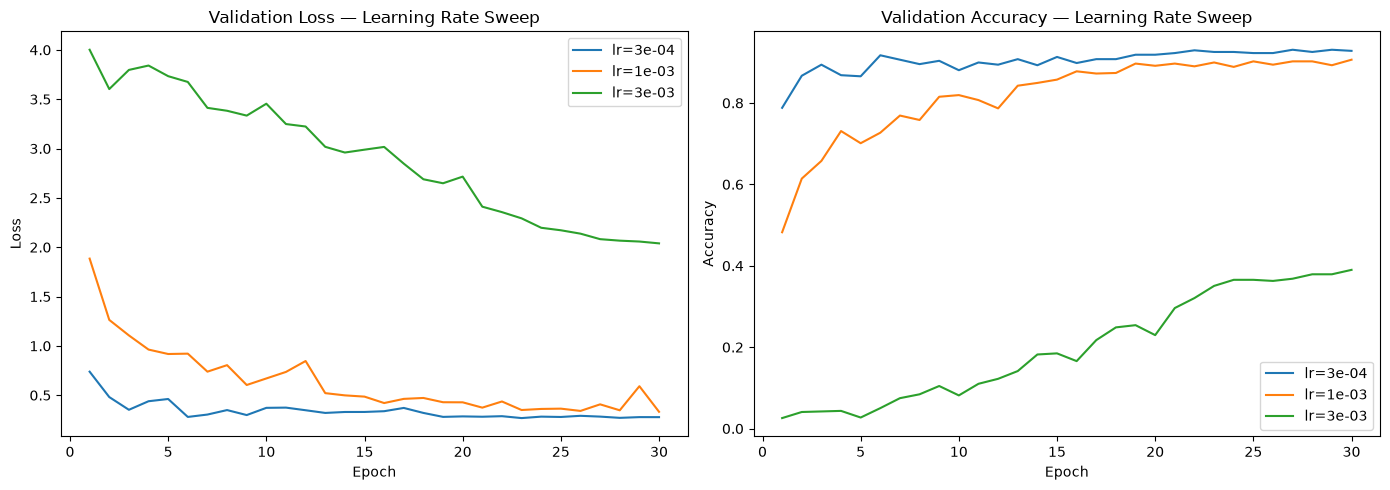

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for lr, history in lr_histories.items():
    epochs = range(1, NUM_EPOCHS + 1)
    axes[0].plot(epochs, history["val_loss"], label=f"lr={lr:.0e}")
    axes[1].plot(epochs, history["val_accuracy"], label=f"lr={lr:.0e}")
axes[0].set_title("Validation Loss — Learning Rate Sweep")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[1].set_title("Validation Accuracy — Learning Rate Sweep")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()


## Weight Decay Sweep

The selected learning rate is fixed while weight decay varies.


In [10]:
weight_decays = [1e-5, 1e-4, 1e-3]
wd_results = []
wd_histories = {}

for wd in weight_decays:
    print(f"\n=== Weight Decay: {wd:.1e} ===")

    model = build_model()
    train_loader = DataLoader(
        OxfordPetSubset(dataset_trainval, train_indices, train_transform),
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )

    optimizer = AdamW(
        model.parameters(),
        lr=selected_lr,
        weight_decay=wd,
    )
    scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

    history = {"train_loss": [], "train_accuracy": [], "val_loss": [], "val_accuracy": [], "learning_rate": []}
    best_val_accuracy = 0.0
    best_epoch = 0
    checkpoint_path = checkpoint_dir / f"e6_wd_{wd:.0e}.pt"

    for epoch in range(NUM_EPOCHS):
        train_loss, train_accuracy = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_accuracy = evaluate(model, val_loader, criterion, device)
        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)
        history["learning_rate"].append(current_lr)

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_epoch = epoch + 1
            torch.save({
                "experiment": "E6",
                "stage": "weight_decay",
                "learning_rate": selected_lr,
                "weight_decay": wd,
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_accuracy": val_accuracy,
            }, checkpoint_path)

        scheduler.step()

        print(
            f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.2%} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.2%} | "
            f"LR: {current_lr:.2e}"
        )

    wd_histories[wd] = history
    wd_results.append({
        "learning_rate": selected_lr,
        "weight_decay": wd,
        "best_epoch": best_epoch,
        "best_val_accuracy": best_val_accuracy,
        "checkpoint": str(checkpoint_path),
    })

wd_results = pd.DataFrame(wd_results)
wd_results



=== Weight Decay: 1.0e-05 ===
Epoch [01/30] | Train Loss: 1.6685 | Train Acc: 56.32% | Val Loss: 0.6733 | Val Acc: 80.30% | LR: 3.00e-04
Epoch [02/30] | Train Loss: 1.0237 | Train Acc: 70.55% | Val Loss: 0.4267 | Val Acc: 86.14% | LR: 2.99e-04
Epoch [03/30] | Train Loss: 0.8469 | Train Acc: 74.35% | Val Loss: 0.4201 | Val Acc: 87.23% | LR: 2.97e-04
Epoch [04/30] | Train Loss: 0.7542 | Train Acc: 77.45% | Val Loss: 0.4800 | Val Acc: 85.19% | LR: 2.93e-04
Epoch [05/30] | Train Loss: 0.6916 | Train Acc: 79.04% | Val Loss: 0.4212 | Val Acc: 86.55% | LR: 2.87e-04
Epoch [06/30] | Train Loss: 0.6126 | Train Acc: 81.69% | Val Loss: 0.3650 | Val Acc: 87.77% | LR: 2.80e-04
Epoch [07/30] | Train Loss: 0.5978 | Train Acc: 81.49% | Val Loss: 0.4283 | Val Acc: 86.28% | LR: 2.71e-04
Epoch [08/30] | Train Loss: 0.5533 | Train Acc: 83.02% | Val Loss: 0.3682 | Val Acc: 88.45% | LR: 2.61e-04
Epoch [09/30] | Train Loss: 0.4820 | Train Acc: 85.60% | Val Loss: 0.3434 | Val Acc: 89.27% | LR: 2.50e-04
Epoch 

,learning_rate,weight_decay,best_epoch,best_val_accuracy,checkpoint
0,0.0003,0.00001,27,0.937500,../experiments/checkpoints/e6_wd_1e-05.pt
1,0.0003,0.00010,24,0.941576,../experiments/checkpoints/e6_wd_1e-04.pt
2,0.0003,0.00100,28,0.940217,../experiments/checkpoints/e6_wd_1e-03.pt


## Select Final Hyperparameter Configuration

The final configuration is selected using validation accuracy.


In [11]:
best_wd_row = wd_results.sort_values("best_val_accuracy", ascending=False).iloc[0]
selected_wd = float(best_wd_row["weight_decay"])
print("Selected learning rate:", selected_lr)
print("Selected weight decay:", selected_wd)
print("Best validation accuracy:", f"{best_wd_row['best_val_accuracy']:.2%}")


Selected learning rate: 0.0003
Selected weight decay: 0.0001
Best validation accuracy: 94.16%


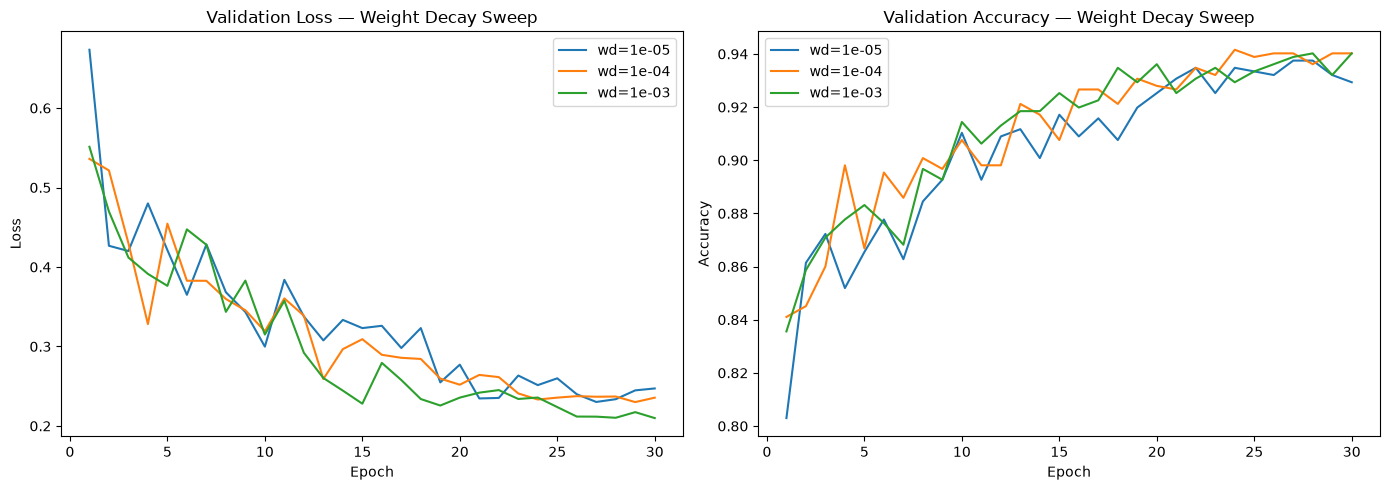

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for wd, history in wd_histories.items():
    epochs = range(1, NUM_EPOCHS + 1)
    axes[0].plot(epochs, history["val_loss"], label=f"wd={wd:.0e}")
    axes[1].plot(epochs, history["val_accuracy"], label=f"wd={wd:.0e}")
axes[0].set_title("Validation Loss — Weight Decay Sweep")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[1].set_title("Validation Accuracy — Weight Decay Sweep")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()


## Final Evaluation on the Test Set

Only the selected hyperparameter configuration is evaluated on the official test set.


In [13]:
best_checkpoint = torch.load(best_wd_row["checkpoint"], map_location=device)
final_model = build_model()
final_model.load_state_dict(best_checkpoint["model_state_dict"])

test_loss, test_accuracy = evaluate(
    final_model,
    test_loader,
    criterion,
    device,
)

print(f"E6 Test Loss: {test_loss:.4f}")
print(f"E6 Test Accuracy: {test_accuracy:.2%}")


E6 Test Loss: 0.3703
E6 Test Accuracy: 90.46%


## E6 Final Result

The selected hyperparameters and final test performance are saved for the later experiment-comparison notebook.


In [14]:
e6_result = pd.DataFrame([{
    "experiment": "E6",
    "model": "ResNet-50",
    "initialization": "ImageNet",
    "trainable_params": sum(p.numel() for p in final_model.parameters() if p.requires_grad),
    "epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": selected_lr,
    "weight_decay": selected_wd,
    "best_epoch": int(best_wd_row["best_epoch"]),
    "best_val_accuracy": float(best_wd_row["best_val_accuracy"]),
    "test_accuracy": test_accuracy,
    "test_loss": test_loss,
    "strategy": "Full Fine-Tuning",
    "tuning": "Learning Rate + Weight Decay",
}])

e6_result


,experiment,model,initialization,trainable_params,epochs,batch_size,learning_rate,weight_decay,best_epoch,best_val_accuracy,test_accuracy,test_loss,strategy,tuning
0,E6,ResNet-50,ImageNet,23583845,30,16,0.0003,0.0001,24,0.941576,0.904606,0.370338,Full Fine-Tuning,Learning Rate + Weight Decay


In [15]:
e6_result.to_csv(results_dir / "e6_hyperparameters.csv", index=False)
lr_results.to_csv(results_dir / "e6_learning_rate_sweep.csv", index=False)
wd_results.to_csv(results_dir / "e6_weight_decay_sweep.csv", index=False)

results_path = results_dir / "experiment_results.csv"
if results_path.exists():
    existing = pd.read_csv(results_path)
    existing = existing[existing["experiment"] != "E6"]
    combined = pd.concat([existing, e6_result], ignore_index=True)
else:
    combined = e6_result.copy()

combined.to_csv(results_path, index=False)
combined


,experiment,model,initialization,trainable_params,epochs,batch_size,learning_rate,weight_decay,best_epoch,best_val_accuracy,best_val_loss,test_accuracy,test_loss,strategy,augmentation,tuning
0,E0,ResNet-50,Random,23583845,30,16,0.0010,0.0001,30,0.338315,2.317437,0.288907,2.500295,NaN,NaN,NaN
1,E1,ResNet-50,ImageNet,75813,30,16,0.0010,0.0001,16,0.937500,0.226684,0.911420,0.292235,Feature Extraction,NaN,NaN
2,E2,ResNet-50,ImageNet,15040549,30,16,0.0010,0.0001,21,0.947011,0.214195,0.911965,0.366784,Layer4 + FC Fine-Tuning,NaN,NaN
3,E3,ResNet-50,ImageNet,22138917,30,16,0.0010,0.0001,26,0.929348,0.265825,0.879531,0.468232,Layer3 + Layer4 Fine-Tuning,NaN,NaN
4,E4,ResNet-50,ImageNet,23583845,30,16,0.0010,0.0001,28,0.913043,0.343463,0.872172,0.486822,Full Fine-Tuning,NaN,NaN
5,E5,ResNet-50,ImageNet,23583845,30,16,0.0010,0.0001,26,0.917120,NaN,0.876261,0.472353,Full Fine-Tuning,color_jitter,NaN
6,E6,ResNet-50,ImageNet,23583845,30,16,0.0003,0.0001,24,0.941576,NaN,0.904606,0.370338,Full Fine-Tuning,NaN,Learning Rate + Weight Decay


# Conclusions

E6 investigates optimization sensitivity through controlled learning-rate and weight-decay sweeps.

The final configuration is selected using validation performance, followed by one final evaluation on the official test set.

The next notebook can aggregate E0–E6 and perform the final evidence-based comparison.
